In [191]:
# Q1(a): Load the dataset and display the first 5 rows

import pandas as pd

# Load the dataset
df = pd.read_csv("loan_approval - loan_approval.csv")

# Display the first 5 rows
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [192]:
# Q1(b): Display the shape of the dataset

print("Shape of the dataset:", df.shape)

Shape of the dataset: (2000, 8)


In [193]:
# Q1(c): Display the data types of each column

print(df.dtypes)

name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object


Interpretation:

The dataset contains 2,000 rows and 8 columns. It includes categorical (object) variables such as name and city, numerical (int64) variables such as income, credit_score, loan_amount, years_employed, and points, and one Boolean target variable (loan_approved). This dataset is suitable for building a Logistic Regression model after preprocessing and data cleaning.

In [194]:
# Q2(a): Check for missing values

print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64


In [195]:
# Q2(b): Handle missing values (if any)

# Remove missing values (if present)
df = df.dropna()

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64


In [196]:
# Q2(c): Identify categorical columns

categorical_columns = df.select_dtypes(include=['object', 'bool']).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['name', 'city', 'loan_approved'], dtype='object')


Interpretation:

The dataset was checked for missing values, and no missing values were found. Therefore, no data cleaning was required for missing data. The categorical columns identified are name, city, and the Boolean target column loan_approved, which will be converted into numerical format during preprocessing.

loan_approved
False    1121
True      879
Name: count, dtype: int64


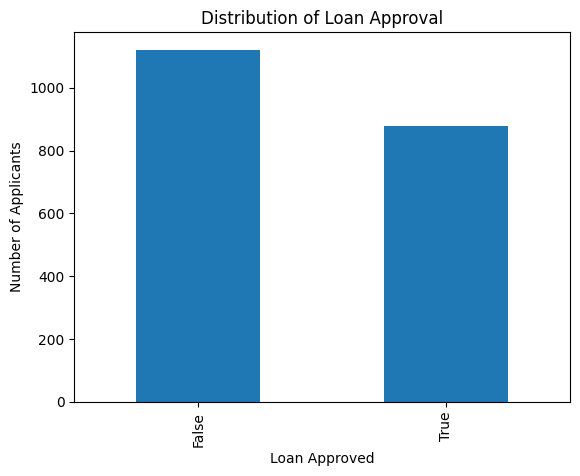

In [197]:
# Q3(a): Display the distribution of the target variable

import matplotlib.pyplot as plt

# Count of loan approval
print(df["loan_approved"].value_counts())

# Bar chart
df["loan_approved"].value_counts().plot(kind="bar")

plt.title("Distribution of Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Number of Applicants")
plt.show()

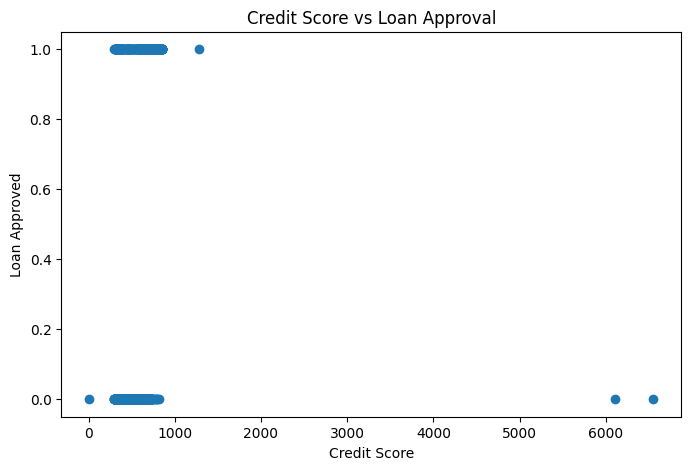

In [198]:
# Q3(b): Relationship between Credit Score and Loan Approval

plt.figure(figsize=(8,5))

plt.scatter(df["credit_score"], df["loan_approved"])

plt.title("Credit Score vs Loan Approval")
plt.xlabel("Credit Score")
plt.ylabel("Loan Approved")

plt.show()

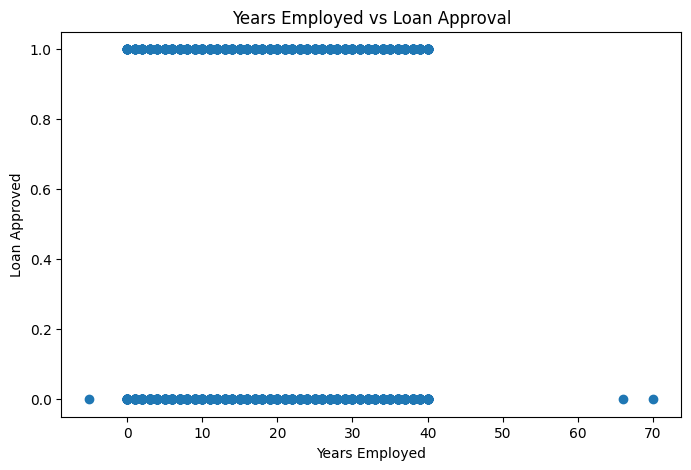

In [199]:
# Q3(c): Relationship between Years Employed and Loan Approval

plt.figure(figsize=(8,5))

plt.scatter(df["years_employed"], df["loan_approved"])

plt.title("Years Employed vs Loan Approval")
plt.xlabel("Years Employed")
plt.ylabel("Loan Approved")

plt.show()

Interpretation:

The target variable distribution shows the number of approved and rejected loan applications. The scatter plot between credit score and loan approval helps understand whether applicants with higher credit scores are more likely to receive loan approval. The second scatter plot shows the relationship between years of employment and loan approval, indicating whether applicants with more work experience have a higher chance of getting their loans approved.

In [200]:
# Q4(a): Detect outliers using the IQR method

Q1 = df["loan_amount"].quantile(0.25)
Q3 = df["loan_amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Display outliers
outliers = df[(df["loan_amount"] < lower_bound) | (df["loan_amount"] > upper_bound)]

print("Number of Outliers:", len(outliers))

Lower Bound: -24198.875
Upper Bound: 74328.125
Number of Outliers: 0


In [201]:
# Q4(b): Treat outliers using capping

df["loan_amount"] = df["loan_amount"].clip(lower=lower_bound, upper=upper_bound)

print("Outliers have been treated using capping.")

Outliers have been treated using capping.


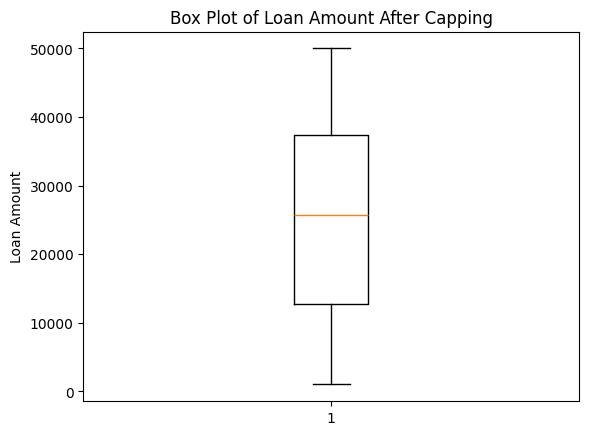

In [202]:
# Q4(c): Visualize loan_amount after capping

import matplotlib.pyplot as plt

plt.boxplot(df["loan_amount"])

plt.title("Box Plot of Loan Amount After Capping")
plt.ylabel("Loan Amount")

plt.show()

Interpretation:

The IQR (Interquartile Range) method was used to detect outliers in the loan_amount column. Values outside the lower and upper bounds were identified as outliers. These outliers were treated using the capping technique, where extreme values were replaced with the calculated boundary values. This reduces the impact of outliers while preserving all records in the dataset.

In [203]:
# Q5: Convert the target variable into numerical format
# and drop unnecessary columns

# Convert loan_approved from True/False to 1/0
df["loan_approved"] = df["loan_approved"].astype(int)

# Drop unnecessary columns
df = df.drop(["name", "city"], axis=1)

# Display the first 5 rows
df.head()

,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810,389,39698,27,50,0
1,44592,729,15446,28,55,0
2,33278,584,11189,13,45,0
3,127196,344,48823,29,50,0
4,66048,496,47174,4,25,0


In [204]:
# Q5: Check the updated data types

print(df.dtypes)

income            int64
credit_score      int64
loan_amount       int64
years_employed    int64
points            int64
loan_approved     int64
dtype: object


Interpretation:

The target variable loan_approved was converted from Boolean (True/False) to numerical values (1/0) for model building. The columns name and city were removed because they are not required for training the Logistic Regression model. The remaining dataset contains only numerical features suitable for machine learning.

In [205]:
# Q6: Define the feature matrix (X) and target variable (y)

X = df.drop("loan_approved", axis=1)
y = df["loan_approved"]

print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (2000, 5)
Target Variable Shape: (2000,)


In [206]:
# Q6: Split the dataset into training and testing sets (80:20)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (1600, 5)
Testing Features: (400, 5)
Training Target: (1600,)
Testing Target: (400,)


Interpretation:

The dataset was divided into feature variables (X) and the target variable (y), where loan_approved is the target. The data was then split into 80% training data and 20% testing data. The training set is used to train the Logistic Regression model, while the testing set is used to evaluate its performance on unseen data.

In [207]:
# Q7: Apply feature scaling using StandardScaler

from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Scale the training and testing data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


Interpretation:

Feature scaling was applied using StandardScaler, which standardizes the feature values by transforming them to have a mean of 0 and a standard deviation of 1. This is important in Logistic Regression because features with different scales can affect the model's performance and convergence. Scaling ensures that all features contribute equally during model training.

In [208]:
# Q8: Train the Logistic Regression model and make predictions

from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
model = LogisticRegression(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

print("Logistic Regression model trained successfully.")
print("Predictions:")
print(y_pred)

Logistic Regression model trained successfully.
Predictions:
[0 1 1 1 1 1 0 1 0 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 1 1 0 1 0 0 1 0 1 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 0 0 1 0 0 1 0 1 1 0 0 1 0
 1 0 1 1 0 1 1 1 1 1 0 0 1 1 1 0 0 1 1 1 0 1 0 1 1 1 1 0 0 1 0 0 0 0 1 0 0
 0 0 0 0 0 1 0 0 0 1 1 0 0 1 1 1 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 1 0 0 1 0 1
 0 0 0 0 0 1 1 0 0 0 1 0 0 1 0 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 0 1 1 1 1 1 0
 0 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 0 1 1 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 1 0 1 0 0 0 0 1 0 0 1
 1 0 1 0 0 1 0 0 1 0 1 1 1 1 0 0 1 1 1 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0 0 1 1
 1 0 1 1 0 1 0 0 0 0 0 1 0 1 1 0 1 1 0 1 1 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1
 0 0 0 1 1 1 1 0 0 1 1 0 0 1 1 0 1 0 1 0 1 0 1 0 1 1 0 1 1 1 1 0 1 1 1 0 1
 1 1 0 1 1 0 0 1 0 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 0 0 1 1 1]


Interpretation:

The Logistic Regression model was trained using the training dataset. After training, the model was used to predict whether a loan application would be approved (1) or not approved (0) for the testing dataset. These predictions will be used to evaluate the model's performance in the next step.

Confusion Matrix:
[[217   0]
 [  0 183]]


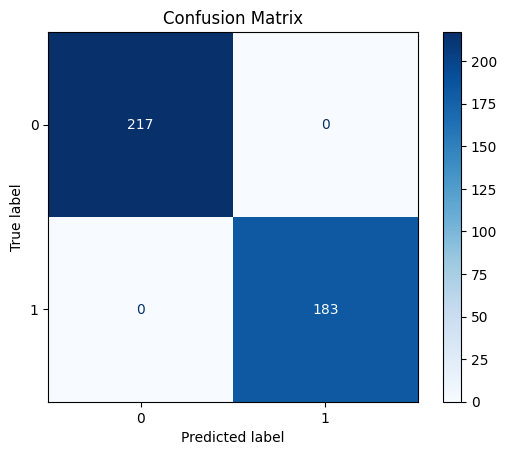

In [209]:
# Q9: Display the Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

Interpretation:

The Confusion Matrix compares the model's predicted values with the actual values. It shows:

True Positives (TP): Correctly predicted approved loans.
True Negatives (TN): Correctly predicted rejected loans.
False Positives (FP): Loans predicted as approved but actually rejected.
False Negatives (FN): Loans predicted as rejected but actually approved.

A good Logistic Regression model should have higher values on the diagonal (correct predictions) and lower values outside the diagonal (incorrect predictions).

AUC Score: 1.0


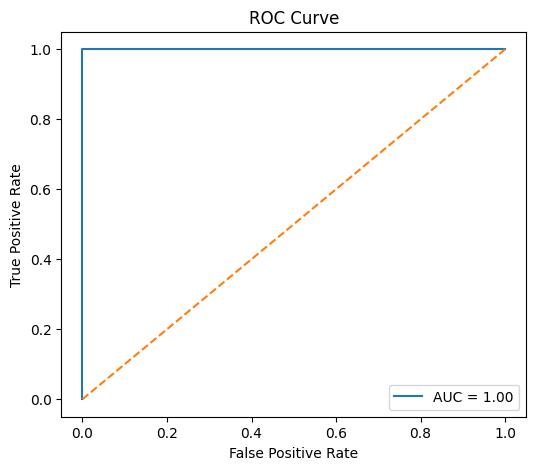

In [210]:
# Q10: Plot the ROC Curve and calculate the AUC Score

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get prediction probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC Score
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

# Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

Interpretation:

The ROC (Receiver Operating Characteristic) Curve shows the performance of the Logistic Regression model at different classification thresholds. The AUC (Area Under the Curve) Score measures the model's ability to distinguish between approved and rejected loan applications.

An AUC Score close to 1.0 indicates excellent model performance.
An AUC Score around 0.5 indicates poor performance, similar to random guessing.
Therefore, a higher AUC Score means the model can classify loan approvals more accurately.

Regression Equation

For Logistic Regression, the equation is:

log(p/1-p)=β0+β1X1+β2X2+....βnXn

where:

p = probability of loan approval


β0= intercept


β1,β2,… = coefficients of the features


Interpretation of Coefficients:

The coefficients represent the effect of each feature on the probability of loan approval.

A positive coefficient increases the likelihood of loan approval.
A negative coefficient decreases the likelihood of loan approval.
Features with larger absolute coefficient values have a stronger influence on the prediction.

